In [35]:
pip install prophet

Note: you may need to restart the kernel to use updated packages.


In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error

# 1. Load and prepare the data
df = pd.read_csv('../data/processed/pv_weather.csv', parse_dates=['LocalTime'])
df.set_index('LocalTime', inplace=True)
df = df.asfreq('h')  # Asegura frecuencia horaria
df.reset_index(inplace=True)  # Make 'LocalTime' a column
df.rename(columns={'LocalTime': 'ds', 'Power(MW)_ActualEnergy': 'y'}, inplace=True)




In [37]:
df

,ds,y,Power(MW)_DA,Power(MW)_HA4,T2M,WS10M,RH2M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PRECTOTCORR,ALLSKY_KT
0,2006-01-01 00:00:00,0.0,0.0,0.0,22.16,4.74,95.38,0.0,0.0,0.00,-999.0
1,2006-01-01 01:00:00,0.0,0.0,0.0,22.18,4.78,95.06,0.0,0.0,0.00,-999.0
2,2006-01-01 02:00:00,0.0,0.0,0.0,22.22,4.80,94.55,0.0,0.0,0.00,-999.0
3,2006-01-01 03:00:00,0.0,0.0,0.0,22.26,4.64,94.14,0.0,0.0,0.00,-999.0
4,2006-01-01 04:00:00,0.0,0.0,0.0,22.25,4.31,94.10,0.0,0.0,0.02,-999.0
...,...,...,...,...,...,...,...,...,...,...,...
8755,2006-12-31 19:00:00,0.0,0.0,0.0,24.01,6.25,85.69,0.0,0.0,0.09,-999.0
8756,2006-12-31 20:00:00,0.0,0.0,0.0,23.93,5.75,86.45,0.0,0.0,0.03,-999.0
8757,2006-12-31 21:00:00,0.0,0.0,0.0,23.90,5.60,86.62,0.0,0.0,0.00,-999.0
8758,2006-12-31 22:00:00,0.0,0.0,0.0,23.89,5.79,86.45,0.0,0.0,0.00,-999.0


In [38]:
# 2. Create extra features for Prophet as regressors
df['hour'] = df['ds'].dt.hour
df['dayofweek'] = df['ds'].dt.dayofweek
df['month'] = df['ds'].dt.month
df['lag1'] = df['y'].shift(1)
df['lag24'] = df['y'].shift(24)
df['rolling_3'] = df['y'].rolling(window=3).mean()

df.dropna(inplace=True)


In [39]:

# 3. Define logistic growth parameters:
#    Set the upper cap to a value slightly above the maximum observed.
cap_value = df['y'].max() * 1.1
df['cap'] = cap_value
df['floor'] = 0  # Minimum value (no negatives)


# 3. Split into training (80%) and test (20%)
train_size = int(len(df) * 0.8)
df_train = df.iloc[:train_size].copy()
df_test = df.iloc[train_size:].copy()



In [40]:
# 4. Initialize Prophet model and add extra regressors
model = Prophet(growth='logistic', interval_width=0.95)

# List of extra regressors (must exist in the DataFrame)
regressors = ['T2M', 'WS10M', 'RH2M',
              'ALLSKY_SFC_SW_DWN', 'CLRSKY_SFC_SW_DWN',
              'PRECTOTCORR', 'ALLSKY_KT',
              'hour', 'dayofweek', 'month',
              'lag1', 'lag24', 'rolling_3']

for reg in regressors:
    model.add_regressor(reg)

# 5. Fit Prophet on the training data
model.fit(df_train)



10:51:25 - cmdstanpy - INFO - Chain [1] start processing
10:51:26 - cmdstanpy - INFO - Chain [1] done processing


In [41]:
# 6. Create a future DataFrame for the test period.
# Since we want to compare on the test set, we use the test DataFrame's columns.
future = df_test[['ds'] + regressors].copy()

# Generate forecast for the test period
forecast = model.predict(future)



ValueError: Expected column "floor".

Test RMSE: 11.042252377472366
Test MAE: 8.45078004527405


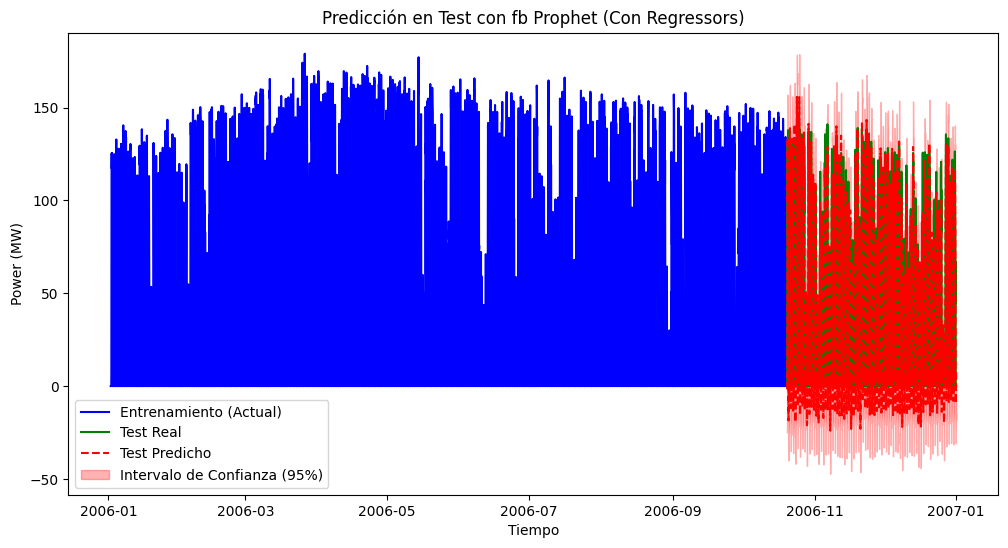

In [ ]:
# 7. Calculate metrics: RMSE and MAE
rmse = np.sqrt(mean_squared_error(df_test['y'], forecast['yhat']))
mae = mean_absolute_error(df_test['y'], forecast['yhat'])
print("Test RMSE:", rmse)
print("Test MAE:", mae)

# 8. Plotting
plt.figure(figsize=(12,6))

# Plot training data (blue)
plt.plot(df_train['ds'], df_train['y'], label='Entrenamiento (Actual)', color='blue')

# Plot actual test data (green)
plt.plot(df_test['ds'], df_test['y'], label='Test Real', color='green')

# Plot Prophet predictions on test (red dashed)
plt.plot(forecast['ds'], forecast['yhat'], label='Test Predicho', color='red', linestyle='--')

# Plot the 95% confidence interval as a shaded area
plt.fill_between(forecast['ds'],
                 forecast['yhat_lower'],
                 forecast['yhat_upper'],
                 color='red', alpha=0.3, label='Intervalo de Confianza (95%)')

plt.title("Predicción en Test con fb Prophet (Con Regressors)")
plt.xlabel("Tiempo")
plt.ylabel("Power (MW)")
plt.legend()
plt.show()

In [ ]:
df

,ds,y,Power(MW)_DA,Power(MW)_HA4,T2M,WS10M,RH2M,ALLSKY_SFC_SW_DWN,CLRSKY_SFC_SW_DWN,PRECTOTCORR,ALLSKY_KT,hour,dayofweek,month,lag1,lag24,rolling_3,cap,floor
24,2006-01-02 00:00:00,0.0,0.0,0.0,22.86,5.30,87.35,0.0,0.0,0.00,-999.0,0,0,1,0.0,0.0,0.000000,196.9275,0
25,2006-01-02 01:00:00,0.0,0.0,0.0,22.80,4.75,87.51,0.0,0.0,0.12,-999.0,1,0,1,0.0,0.0,0.000000,196.9275,0
26,2006-01-02 02:00:00,0.0,0.0,0.0,22.73,4.42,87.52,0.0,0.0,0.12,-999.0,2,0,1,0.0,0.0,0.000000,196.9275,0
27,2006-01-02 03:00:00,0.0,0.0,0.0,22.68,4.46,87.54,0.0,0.0,0.12,-999.0,3,0,1,0.0,0.0,0.000000,196.9275,0
28,2006-01-02 04:00:00,0.0,0.0,0.0,22.64,4.56,87.93,0.0,0.0,0.00,-999.0,4,0,1,0.0,0.0,0.000000,196.9275,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8755,2006-12-31 19:00:00,0.0,0.0,0.0,24.01,6.25,85.69,0.0,0.0,0.09,-999.0,19,6,12,0.0,0.0,3.552778,196.9275,0
8756,2006-12-31 20:00:00,0.0,0.0,0.0,23.93,5.75,86.45,0.0,0.0,0.03,-999.0,20,6,12,0.0,0.0,0.000000,196.9275,0
8757,2006-12-31 21:00:00,0.0,0.0,0.0,23.90,5.60,86.62,0.0,0.0,0.00,-999.0,21,6,12,0.0,0.0,0.000000,196.9275,0
8758,2006-12-31 22:00:00,0.0,0.0,0.0,23.89,5.79,86.45,0.0,0.0,0.00,-999.0,22,6,12,0.0,0.0,0.000000,196.9275,0


In [ ]:
print("Full df shape:", df.shape)
print("Training set shape:", df_train.shape)

Full df shape: (8736, 19)
Training set shape: (6988, 19)
